# SepsisGuard — GRPO Training Notebook

Train 4 multi-agent roles (Nurse, Lab, Pharmacist, Physician) using TRL GRPO with Unsloth 4-bit quantization.

This notebook:
1. Loads a quantized Qwen 2.5-3B model
2. Connects to the live SepsisGuard environment
3. Collects initial rollouts for the prompt dataset
4. Runs GRPO training with online environment rewards
5. Evaluates and plots reward improvement vs heuristic baseline

In [1]:
!pip install -q -U "unsloth[colab-new]" openenv-core "trl>=0.12" vllm datasets matplotlib
!pip install -q requests httpx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.1/433.1 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from unsloth import FastLanguageModel

MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
model, tokenizer = FastLanguageModel.from_pretrained(
    MODEL_NAME, max_seq_length=4096, load_in_4bit=True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r=16, lora_alpha=16, lora_dropout=0,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
)
FastLanguageModel.for_inference(model)
print(f"Model loaded: {MODEL_NAME}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.19.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Model loaded: unsloth/Qwen2.5-3B-Instruct-bnb-4bit


In [3]:
import os
if not os.path.exists("/content/sepsisguard"):
    !git clone https://huggingface.co/spaces/Jishnu-Vijayan-03/Sepsis-Guard /content/sepsisguard
os.chdir("/content/sepsisguard")

import sys
if "/content/sepsisguard" not in sys.path:
    sys.path.insert(0, "/content/sepsisguard")

!pip install -q -e "/content/sepsisguard"
print("Repo ready:", os.listdir("/content/sepsisguard"))

Cloning into '/content/sepsisguard'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 95 (delta 42), reused 0 (delta 0), pack-reused 4 (from 1)
Receiving objects: 100% (95/95), 259.45 KiB | 2.47 MiB/s, done.
Resolving deltas: 100% (42/42), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sepsisguard (pyproject.toml) ... done
Repo ready: ['pyproject.toml', 'server', 'training', 'requirements.txt', 'Dockerfile', 'inference.py', 'README.md', '.env.example', 'models.py', 'tests', '.gitignore', 'agents', '.gitattributes', 'openenv.yaml', 'uv.lock', 'CLAUDE.md', '.git']


In [5]:
!pip install -q -e "/content/sepsisguard"

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sepsisguard (pyproject.toml) ... done


In [21]:
%cd /content/sepsisguard
import os
import signal
import subprocess
import time
import requests

UVICORN_CMD = "uvicorn server.app:app --host 0.0.0.0 --port 7860"
HEALTH_URL = "http://127.0.0.1:7860/health"

def _find_server_pids():
    # Match the specific SepsisGuard uvicorn command to avoid killing unrelated processes.
    proc = subprocess.run(
        ["bash", "-lc", f"pgrep -f '{UVICORN_CMD}'"],
        capture_output=True, text=True
    )
    if proc.returncode != 0 or not proc.stdout.strip():
        return []
    return [int(x) for x in proc.stdout.strip().splitlines() if x.strip().isdigit()]

def _stop_existing_server():
    pids = _find_server_pids()
    if not pids:
        print("No existing SepsisGuard uvicorn process found.")
        return
    print(f"Stopping existing uvicorn process(es): {pids}")
    for pid in pids:
        try:
            os.kill(pid, signal.SIGTERM)
        except OSError:
            pass
    time.sleep(1.5)

    # Force kill if still alive.
    survivors = _find_server_pids()
    for pid in survivors:
        try:
            os.kill(pid, signal.SIGKILL)
        except OSError:
            pass
    if survivors:
        print(f"Force-killed lingering process(es): {survivors}")

def _start_server():
    subprocess.run(
        ["bash", "-lc", f"nohup {UVICORN_CMD} > /content/uvicorn.log 2>&1 &"],
        check=False
    )

def _wait_for_health(timeout_s=30):
    t0 = time.time()
    last_err = None
    while time.time() - t0 < timeout_s:
        try:
            r = requests.get(HEALTH_URL, timeout=3)
            if r.ok:
                return True
        except Exception as e:
            last_err = e
        time.sleep(1)
    print(f"Server health check timed out at {HEALTH_URL}. Last error: {last_err}")
    return False

_stop_existing_server()
_start_server()
if _wait_for_health(timeout_s=30):
    print("Local SepsisGuard server is healthy at http://127.0.0.1:7860")
else:
    print("Server started but health check failed. Inspect logs: /content/uvicorn.log")

/content
No existing SepsisGuard uvicorn process found.
Local SepsisGuard server is healthy at http://127.0.0.1:7860


In [22]:
!curl "http://127.0.0.1:7860/health"

{"status":"healthy"}

In [23]:
import os, requests, time

# If notebook and server run on the SAME Colab VM, localhost works.
# If your server is outside Colab, set ENV_BASE_URL to a public tunnel URL.
ENV_URL = os.environ.get("ENV_BASE_URL", "http://127.0.0.1:7860")

class EnvClient:
    def __init__(self, base_url):
        self.base_url = base_url.rstrip("/")

    def reset(self, task_name, seed, session_id=None):
        headers = {"X-Session-Id": session_id} if session_id else {}
        r = requests.post(f"{self.base_url}/reset",
                          json={"task_name": task_name, "seed": seed},
                          headers=headers, timeout=30)
        r.raise_for_status()
        return r.json()

    def step(self, actions, session_id=None):
        headers = {"X-Session-Id": session_id} if session_id else {}
        r = requests.post(f"{self.base_url}/step",
                          json={"actions": actions},
                          headers=headers, timeout=30)
        r.raise_for_status()
        return r.json()

    def create_session(self):
        r = requests.post(f"{self.base_url}/session", timeout=10)
        r.raise_for_status()
        return r.json()["session_id"]

    def delete_session(self, session_id):
        try:
            requests.delete(f"{self.base_url}/session/{session_id}", timeout=5)
        except Exception:
            pass

# Wait briefly for server readiness so first /reset doesn't fail noisily.
ready = False
for _ in range(15):
    try:
        requests.get(f"{ENV_URL}/state", timeout=3).raise_for_status()
        ready = True
        break
    except Exception:
        time.sleep(1)
if not ready:
    raise RuntimeError(
        f"Server not reachable at {ENV_URL}. Start uvicorn or set ENV_BASE_URL to your reachable URL."
    )

env = EnvClient(ENV_URL)
info = env.reset(task_name="task1_textbook", seed=42)
print(f"Connected to {ENV_URL}")
print(f"Tick: {info['info']['tick']}, Roles: {list(info['observations'].keys())}")

Connected to http://127.0.0.1:7860
Tick: 1, Roles: ['nurse', 'lab', 'pharmacist', 'physician']


In [ ]:
import os
import sys
import json
import pickle
import requests
import torch
import glob
import re
from datetime import datetime
from tqdm.auto import tqdm
sys.path.insert(0, "/content/sepsisguard")

from training.prompts import build_role_prompt, SYSTEM_PROMPTS
from training.rollout_collector import parse_action
from agents.nurse import HeuristicNurse
from agents.lab import HeuristicLab
from agents.pharmacist import HeuristicPharmacist
from agents.physician import HeuristicPhysician

ROLES = ("nurse", "lab", "pharmacist", "physician")

N_EPISODES = 4
SEEDS = list(range(42, 42 + N_EPISODES))
TASK = "task1_textbook"
MAX_NEW_TOKENS = 256
MAX_TICKS_PER_EP = 48
LOG_EVERY_N_TICKS = 2
NUM_RETURN_SEQUENCES = 4  # GRPO needs multiple completions per prompt
HEURISTIC_MIX_RATIO = 0.25  # 25% expert demonstrations

FORCE_REGENERATE = True

heuristic_agents = {
    "nurse": HeuristicNurse(),
    "lab": HeuristicLab(),
    "pharmacist": HeuristicPharmacist(),
    "physician": HeuristicPhysician(),
}

save_dir = "/content/sepsisguard/saved_rollouts"
os.makedirs(save_dir, exist_ok=True)

latest_jsonl_path = f"{save_dir}/latest_rollouts_{TASK}.jsonl"
latest_pkl_path = f"{save_dir}/latest_rollouts_{TASK}.pkl"

pkl_files = glob.glob(f"{save_dir}/*{TASK}*.pkl")
jsonl_files = glob.glob(f"{save_dir}/*{TASK}*.jsonl")
pkl_files.sort(reverse=True)
jsonl_files.sort(reverse=True)

rollouts = []
fallback_steps = 0

if not FORCE_REGENERATE and pkl_files:
    latest_pkl = pkl_files[0]
    print(f"Found cached PKL for task '{TASK}'. Loading: {os.path.basename(latest_pkl)}")
    with open(latest_pkl, "rb") as f:
        rollouts = pickle.load(f)
elif not FORCE_REGENERATE and jsonl_files:
    latest_jsonl_file = jsonl_files[0]
    print(f"Found cached JSONL for task '{TASK}'. Loading: {os.path.basename(latest_jsonl_file)}")
    with open(latest_jsonl_file, "r", encoding="utf-8") as f:
        rollouts = [json.loads(line) for line in f]
else:
    if FORCE_REGENERATE:
        print(f"FORCE_REGENERATE=True. Generating fresh rollouts with updated prompts...")
    else:
        print(f"No cached data found for task '{TASK}'. Starting rollout generation...")
    timestamp = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
    stream_jsonl_path = f"{save_dir}/rollouts_stream_{TASK}_{timestamp}.jsonl"
    stream_pkl_path = f"{save_dir}/rollouts_stream_{TASK}_{timestamp}.pkl"
    print(f"Streaming rollout rows to: {stream_jsonl_path}")

    def _llm_action(role, role_obs, num_sequences=1):
        """Generate LLM completions. Returns list of (action, prompt, completion) tuples."""
        prompt = build_role_prompt(role_obs, role)
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        results = []
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=True, temperature=0.7, top_p=0.9,
                num_return_sequences=num_sequences,
            )
        for out in outputs:
            raw = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            match = re.search(r'\{.*?\}', raw, re.DOTALL)
            clean = match.group(0) if match else raw
            action = parse_action(clean, role)
            results.append((action, prompt, clean))
        return results

    def _heuristic_demo(role, role_obs):
        """Generate an expert demonstration from the heuristic agent."""
        prompt = build_role_prompt(role_obs, role)
        action = heuristic_agents[role].decide(role_obs)
        completion = json.dumps(action, ensure_ascii=True)
        return action, prompt, completion

    with open(stream_jsonl_path, "w", encoding="utf-8") as stream_f:
        for ep_idx, seed in enumerate(tqdm(SEEDS, desc="Collecting episodes")):
            sid = env.create_session()
            bundle = env.reset(task_name=TASK, seed=seed, session_id=sid)
            done = False
            tick = 0

            try:
                with tqdm(total=MAX_TICKS_PER_EP, desc=f"Ep {ep_idx+1} (seed={seed})", leave=False) as tick_bar:
                    while not done and tick < MAX_TICKS_PER_EP:
                        obs = bundle["observations"]
                        step_actions = {}
                        batch_this_tick = []

                        for role in ROLES:
                            # LLM completions (multiple per prompt for GRPO)
                            llm_results = _llm_action(role, obs[role], num_sequences=NUM_RETURN_SEQUENCES)
                            step_actions[role] = llm_results[0][0]  # use first for stepping

                            for action, prompt, completion in llm_results:
                                batch_this_tick.append({
                                    "prompt": prompt,
                                    "completion": completion,
                                    "role": role,
                                    "env_reward_placeholder": None,
                                    "episode": ep_idx + 1,
                                    "seed": seed,
                                    "tick": tick + 1,
                                    "source": "llm",
                                })

                            # Heuristic expert demonstration
                            import random
                            if random.random() < HEURISTIC_MIX_RATIO:
                                h_action, h_prompt, h_completion = _heuristic_demo(role, obs[role])
                                batch_this_tick.append({
                                    "prompt": h_prompt,
                                    "completion": h_completion,
                                    "role": role,
                                    "env_reward_placeholder": None,
                                    "episode": ep_idx + 1,
                                    "seed": seed,
                                    "tick": tick + 1,
                                    "source": "heuristic",
                                })

                        used_fallback = False
                        try:
                            bundle = env.step(step_actions, session_id=sid)
                        except requests.HTTPError as e:
                            used_fallback = True
                            fallback_steps += 1
                            print(f"[ep {ep_idx+1} tick {tick+1}] /step failed: {e}. Using heuristic fallback.")
                            fallback_actions = {r: heuristic_agents[r].decide(obs[r]) for r in ROLES}
                            bundle = env.step(fallback_actions, session_id=sid)

                        rewards = bundle.get("rewards", {})
                        for row in batch_this_tick:
                            row["env_reward_placeholder"] = float(rewards.get(row["role"], 0.0))
                            row["used_fallback_step"] = used_fallback
                            rollouts.append(row)
                            stream_f.write(json.dumps(row, ensure_ascii=True) + "\n")

                        stream_f.flush()
                        done = bool(bundle.get("done", False))
                        tick += 1
                        tick_bar.update(1)

                        if tick % LOG_EVERY_N_TICKS == 0 or done:
                            print(
                                f"[ep {ep_idx+1}/{N_EPISODES}] seed={seed} tick={tick} done={done} "
                                f"rows={len(rollouts)} fallback_steps={fallback_steps}"
                            )
            finally:
                env.delete_session(sid)

            print(f"[episode {ep_idx+1}/{N_EPISODES}] seed={seed} ticks={tick} total_rows={len(rollouts)}")

    if not rollouts:
        raise RuntimeError("Rollout collection produced 0 rows.")

    with open(stream_pkl_path, "wb") as f:
        pickle.dump(rollouts, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Updating 'latest' files for task '{TASK}'...")
    with open(latest_jsonl_path, "w", encoding="utf-8") as f:
        for row in rollouts:
            f.write(json.dumps(row, ensure_ascii=True) + "\n")
    with open(latest_pkl_path, "wb") as f:
        pickle.dump(rollouts, f, protocol=pickle.HIGHEST_PROTOCOL)

print("\n--- Summary ---")
print(f"Total Rows: {len(rollouts)} rollout rows")
print(f"Fallback steps used during generation: {fallback_steps}")
if rollouts:
    llm_rows = [r for r in rollouts if r.get("source") == "llm"]
    heur_rows = [r for r in rollouts if r.get("source") == "heuristic"]
    print(f"LLM completions: {len(llm_rows)} | Heuristic demos: {len(heur_rows)}")
    print(f"Seeds used: {SEEDS}")
    print(f"Roles: {set(r['role'] for r in rollouts)}")
    rewards_by_role = {}
    for r in rollouts:
        rewards_by_role.setdefault(r["role"], []).append(r["env_reward_placeholder"])
    for role, rews in rewards_by_role.items():
        avg = sum(rews) / len(rews)
        print(f"  {role}: mean_reward={avg:.3f} min={min(rews):.1f} max={max(rews):.1f} n={len(rews)}")
    print(f"Sample prompt length: {len(rollouts[0]['prompt'])} chars")
    print(f"Sample completion: {rollouts[0]['completion'][:150]}...")


In [10]:
!curl "http://127.0.0.1:7860/health"

{"status":"healthy"}

In [11]:
import json
from datasets import Dataset

def get_clinical_state(prompt_str):
    """Strips out the changing simulation counters to find the true clinical state."""
    try:
        # 1. Extract the JSON part of the observation from the prompt
        obs_start = prompt_str.find('Observation:\n') + 13
        obs_end = prompt_str.rfind('\nAction (JSON):')

        # If we can't find the markers, just return the raw prompt safely
        if obs_start < 13 or obs_end == -1: return prompt_str

        obs_json_str = prompt_str[obs_start:obs_end]
        obs_dict = json.loads(obs_json_str)

        # 2. Delete the fields that change every tick but don't matter clinically
        keys_to_remove = ["tick", "reward", "cumulative_reward", "last_action_result", "normalized_score"]
        for key in keys_to_remove:
            obs_dict.pop(key, None)

        # 3. Return the prompt with the "clean" observation
        clean_obs_str = json.dumps(obs_dict, sort_keys=True)
        return prompt_str[:obs_start] + clean_obs_str + prompt_str[obs_end:]

    except Exception:
        # Fallback if parsing fails
        return prompt_str

# --- Smart Deduplication ---
unique_prompts = {}

for r in rollouts:
    # Get a version of the prompt without tick numbers and rewards
    core_state = get_clinical_state(r["prompt"])

    # Store it in a dictionary (this naturally overwrites duplicates!)
    # We save the original prompt so the model still sees valid tick numbers during training
    if core_state not in unique_prompts:
        unique_prompts[core_state] = r["prompt"]

# Now build your dataset from the unique values
train_dataset = Dataset.from_list([{"prompt": p} for p in unique_prompts.values()])

print(f"Original rollouts: {len(rollouts)}")
print(f"Unique clinical scenarios: {len(unique_prompts)}")

Original rollouts: 768
Unique clinical scenarios: 604


In [ ]:
import torch
import json
import re
from datasets import Dataset
from trl import GRPOTrainer, GRPOConfig
from transformers import TrainerCallback
from training.reward_shaping import make_online_sepsis_reward_fn, format_reward_fn

FastLanguageModel.for_training(model)

# --- 1. SMART PROMPT DEDUPLICATION ---
def get_clinical_state(prompt_str):
    try:
        obs_start = prompt_str.find('Observation:\n') + 13
        obs_end = prompt_str.rfind('\nAction (JSON):')
        if obs_start < 13 or obs_end == -1: return prompt_str
        obs_json_str = prompt_str[obs_start:obs_end]
        obs_dict = json.loads(obs_json_str)
        for key in ["tick", "reward", "cumulative_reward", "last_action_result",
                     "normalized_score", "done", "metadata"]:
            obs_dict.pop(key, None)
        clean_obs_str = json.dumps(obs_dict, sort_keys=True)
        return prompt_str[:obs_start] + clean_obs_str + prompt_str[obs_end:]
    except Exception:
        return prompt_str

unique_prompts = {}
for r in rollouts:
    core_state = get_clinical_state(r["prompt"])
    if core_state not in unique_prompts:
        unique_prompts[core_state] = r["prompt"]

train_dataset = Dataset.from_list([{"prompt": p} for p in unique_prompts.values()])
print(f"Dataset: {len(unique_prompts)} unique prompts (from {len(rollouts)} total rows).")


# --- 2. HARDWARE SETUP ---
has_cuda = torch.cuda.is_available()
if has_cuda:
    major, _ = torch.cuda.get_device_capability()
    use_bf16 = major >= 8
    use_fp16 = not use_bf16
    print(f"CUDA device: {torch.cuda.get_device_name(0)} | bf16={use_bf16} fp16={use_fp16}")
else:
    use_bf16 = False
    use_fp16 = False
    print("CUDA not available. Using fp32 precision.")


# --- 3. GRPO CONFIGURATION ---
# Tuning rationale:
#   num_generations=6: more diversity -> non-zero reward variance -> actual GRPO gradients
#   learning_rate=5e-6: 4x lower than before to prevent mode collapse
#   max_steps=300: compensate for lower LR
#   gradient_checkpointing=True: saves ~30% VRAM on T4
cfg = GRPOConfig(
    output_dir="./sepsis-grpo",
    num_generations=6,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    max_steps=300,
    learning_rate=5e-6,
    warmup_steps=30,
    logging_steps=1,
    save_steps=100,
    max_prompt_length=3000,
    max_completion_length=256,
    bf16=use_bf16,
    fp16=use_fp16,
    report_to="none",
    gradient_checkpointing=True,
)

# Reward fn: runs 12-tick eval windows (4 warmup + 8 inject), thread-parallel,
# baseline cached per (seed, role). Quick-rejects noop/missing-patient actions.
reward_fn_env_obj = make_online_sepsis_reward_fn(
    env_url=ENV_URL,
    task_name=TASK,
    seed=42,
    warmup_ticks=4,
    inject_ticks=8,
    max_workers=4,
)

def reward_fn_env(*args, **kwargs):
    return reward_fn_env_obj(*args, **kwargs)
reward_fn_env.__name__ = "reward_fn_env"

reward_log = {"steps": [], "env_reward": [], "format_reward": []}


# --- 4. REWARD LOGGER WITH COLLAPSE DETECTION ---
class RewardLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "kl" in logs:
            reward_log["steps"].append(state.global_step)
            reward_log["env_reward"].append(logs.get("rewards/reward_fn_env/mean", 0.0))
            reward_log["format_reward"].append(logs.get("rewards/format_reward_fn/mean", 0.0))

        if state.global_step % 50 == 0 and state.global_step > 0:
            sample_prompt = train_dataset[0]["prompt"]
            inputs = tokenizer(sample_prompt, return_tensors="pt").to(model.device)
            model.eval()
            with torch.no_grad():
                out = model.generate(**inputs, max_new_tokens=256, do_sample=False)
            model.train()

            generated = tokenizer.decode(
                out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
            )

            clean_json = "Parse Failed - No JSON found"
            match = re.search(r'\{.*?\}', generated, re.DOTALL)
            if match:
                clean_json = match.group(0)

            collapse_warning = ""
            if '"..."' in clean_json or '"rationale": ""' in clean_json:
                collapse_warning = " [WARNING: possible mode collapse]"

            print(f"\n=== Step {state.global_step} sample{collapse_warning} ===")
            print(f"Raw:\n{generated[:200]}...")
            print(f"Extracted:\n{clean_json}")
            print("=" * 40)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[reward_fn_env, format_reward_fn],
    args=cfg,
    train_dataset=train_dataset,
    callbacks=[RewardLogger()],
)

print(f"Training: {cfg.max_steps} steps, lr={cfg.learning_rate}, "
      f"batch={cfg.per_device_train_batch_size}x{cfg.gradient_accumulation_steps}, "
      f"gen={cfg.num_generations}, grad_ckpt={cfg.gradient_checkpointing}")
print("Starting GRPO training...")
trainer.train()
print("Training complete.")

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import os
import shutil

# --- 1. Define Paths ---
# Local Colab Paths
local_lora_path = "./sepsis-grpo-lora"
local_merged_path = "./sepsis-grpo-merged"

# Google Drive Paths
drive_base_dir = "/content/drive/MyDrive/sepsis_model_exports"
drive_lora_path = os.path.join(drive_base_dir, "sepsis-grpo-lora")
drive_merged_path = os.path.join(drive_base_dir, "sepsis-grpo-merged")

os.makedirs(drive_base_dir, exist_ok=True)

# --- 2. Save Locally (Fastest) ---
print(f"💾 Saving LoRA adapters locally to {local_lora_path} ...")
model.save_pretrained(local_lora_path)
tokenizer.save_pretrained(local_lora_path)

print(f"💾 Saving Merged 16-bit model locally to {local_merged_path} ...")
print("(This may take a few minutes...)")
model.save_pretrained_merged(
    local_merged_path,
    tokenizer,
    save_method="merged_16bit",
)
print("✅ Local save complete!")

# --- 3. Copy to Google Drive (Safe Backup) ---
print(f"\n📂 Copying LoRA adapters to Drive: {drive_lora_path} ...")
if os.path.exists(drive_lora_path):
    shutil.rmtree(drive_lora_path) # Overwrite if it already exists
shutil.copytree(local_lora_path, drive_lora_path)

print(f"📂 Copying Merged model to Drive: {drive_merged_path} ...")
print("(Copying 6GB+ to Drive... please wait...)")
if os.path.exists(drive_merged_path):
    shutil.rmtree(drive_merged_path)
shutil.copytree(local_merged_path, drive_merged_path)

print("\n🎉 Success! Models are saved locally and fully backed up to Google Drive.")

💾 Saving LoRA adapters locally to ./sepsis-grpo-lora ...
💾 Saving Merged 16-bit model locally to ./sepsis-grpo-merged ...
(This may take a few minutes...)


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [03:06<00:00, 93.41s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [03:25<00:00, 102.61s/it]


Unsloth: Merge process complete. Saved to `/content/sepsisguard/sepsis-grpo-merged`
✅ Local save complete!

📂 Copying LoRA adapters to Drive: /content/drive/MyDrive/sepsis_model_exports/sepsis-grpo-lora ...
📂 Copying Merged model to Drive: /content/drive/MyDrive/sepsis_model_exports/sepsis-grpo-merged ...
(Copying 6GB+ to Drive... please wait...)

🎉 Success! Models are saved locally and fully backed up to Google Drive.


In [24]:
import requests, json, re
import torch
from tqdm.auto import tqdm
from agents.nurse import HeuristicNurse
from agents.lab import HeuristicLab
from agents.pharmacist import HeuristicPharmacist
from agents.physician import HeuristicPhysician
from training.prompts import build_role_prompt

def run_episode(env_client, task_name, seed, agent_fn, session_id=None):
    """Run one episode. agent_fn(role, obs) -> action dict."""
    bundle = env_client.reset(task_name=task_name, seed=seed, session_id=session_id)
    done = False
    step_rewards = []

    # We can add an inner progress bar for the ticks within an episode if desired,
    # but usually episode-level tracking is enough for eval loops.
    while not done:
        obs = bundle["observations"]
        actions = {}
        for role in ("nurse", "lab", "pharmacist", "physician"):
            actions[role] = agent_fn(role, obs[role])
        bundle = env_client.step(actions, session_id=session_id)
        step_rewards.append(bundle.get("team_reward", 0.0))
        done = bundle["done"]

    grader = requests.get(f"{env_client.base_url}/grader",
                          headers={"X-Session-Id": session_id} if session_id else {},
                          timeout=30).json()
    return grader.get("score", 0.0), step_rewards

nurse_h, lab_h, pharma_h, phys_h = HeuristicNurse(), HeuristicLab(), HeuristicPharmacist(), HeuristicPhysician()
heuristic_agents = {"nurse": nurse_h, "lab": lab_h, "pharmacist": pharma_h, "physician": phys_h}

def heuristic_agent_fn(role, obs):
    return heuristic_agents[role].decide(obs)

def make_llm_agent_fn(model, tokenizer, target_role):
    def agent_fn(role, obs):
        if role != target_role:
            return heuristic_agents[role].decide(obs)
        prompt = build_role_prompt(obs, role)
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            # NOTE: Increased max_new_tokens to 256 to ensure complete JSON output
            out = model.generate(**inputs, max_new_tokens=256, do_sample=False)
        text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

        # Robust JSON extraction
        try:
            # First try direct parse in case it's perfectly clean
            parsed = json.loads(text.strip())
            if isinstance(parsed, dict) and "operation" in parsed:
                return parsed
        except Exception:
            pass

        # Fallback to regex extraction (the "Magic Fix" we used earlier)
        match = re.search(r'\{.*?\}', text, re.DOTALL)
        if match:
            try:
                parsed = json.loads(match.group(0))
                if isinstance(parsed, dict) and "operation" in parsed:
                    return parsed
            except Exception:
                pass

        # Final fallback if the model completely failed
        return heuristic_agents[role].decide(obs)

    return agent_fn

N_EVAL = 5
EVAL_TASKS = ["task1_textbook"]
ROLES = ("nurse", "lab", "pharmacist", "physician")

print("=" * 60)
print("EVALUATION: Heuristic Baseline vs Trained Model")
print("=" * 60)

# --- Evaluate Heuristics ---
baseline_scores = {}
print("\n--- Running Baseline (Heuristics Only) ---")
for task in EVAL_TASKS:
    scores = []
    # Create a progress bar for the baseline evaluation of this task
    with tqdm(total=N_EVAL, desc=f"Baseline: {task}") as pbar:
        for ep in range(N_EVAL):
            sid = env.create_session()
            score, _ = run_episode(env, task, seed=100 + ep, agent_fn=heuristic_agent_fn, session_id=sid)
            scores.append(score)
            env.delete_session(sid)
            pbar.update(1) # Update the progress bar after each episode

    baseline_scores[task] = scores
    print(f"Heuristic [{task}]: mean={sum(scores)/len(scores):.4f}  scores={[round(s,3) for s in scores]}\n")

# --- Evaluate Trained Model ---
FastLanguageModel.for_inference(model)
trained_scores = {}

print("--- Running Trained Model Evaluations ---")
for task in EVAL_TASKS:
    for target_role in ROLES:
        llm_fn = make_llm_agent_fn(model, tokenizer, target_role)
        scores = []

        # Create a progress bar for the LLM evaluation of this specific role
        with tqdm(total=N_EVAL, desc=f"LLM [{target_role}] on {task}") as pbar:
            for ep in range(N_EVAL):
                sid = env.create_session()
                score, _ = run_episode(env, task, seed=100 + ep, agent_fn=llm_fn, session_id=sid)
                scores.append(score)
                env.delete_session(sid)
                pbar.update(1) # Update the progress bar after each episode

        key = f"{task}_{target_role}"
        trained_scores[key] = scores
        mean_s = sum(scores) / len(scores)
        base_mean = sum(baseline_scores[task]) / len(baseline_scores[task])
        delta = mean_s - base_mean
        print(f"Result -> Trained [{task}/{target_role}]: mean={mean_s:.4f}  delta={delta:+.4f}  scores={[round(s,3) for s in scores]}\n")

EVALUATION: Heuristic Baseline vs Trained Model

--- Running Baseline (Heuristics Only) ---


Baseline: task1_textbook:   0%|          | 0/5 [00:00<?, ?it/s]

Heuristic [task1_textbook]: mean=0.8175  scores=[0.938, 0.95, 0.775, 0.938, 0.487]

--- Running Trained Model Evaluations ---


LLM [nurse] on task1_textbook:   0%|          | 0/5 [00:00<?, ?it/s]

Result -> Trained [task1_textbook/nurse]: mean=0.7525  delta=-0.0650  scores=[0.938, 0.95, 0.487, 0.938, 0.45]



...

Result -> Trained [task1_textbook/lab]: mean=0.5100  delta=-0.3075  scores=[0.65, 0.475, 0.487, 0.45, 0.487]



LLM [pharmacist] on task1_textbook:   0%|          | 0/5 [00:00<?, ?it/s]

Result -> Trained [task1_textbook/pharmacist]: mean=0.5825  delta=-0.2350  scores=[0.738, 0.863, 0.287, 0.738, 0.287]



LLM [physician] on task1_textbook:   0%|          | 0/5 [00:00<?, ?it/s]

Result -> Trained [task1_textbook/physician]: mean=0.6000  delta=-0.2175  scores=[0.6, 0.6, 0.6, 0.6, 0.6]



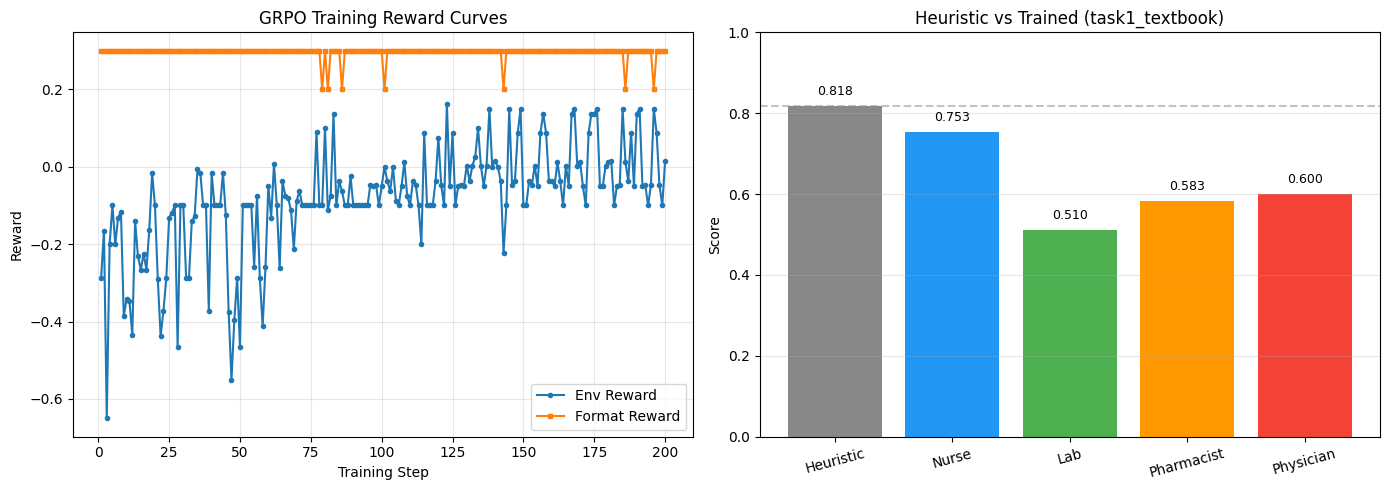

Plot saved to training_results.png


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if reward_log["steps"]:
    axes[0].plot(reward_log["steps"], reward_log["env_reward"], label="Env Reward", marker="o", markersize=3)
    axes[0].plot(reward_log["steps"], reward_log["format_reward"], label="Format Reward", marker="s", markersize=3)
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Reward")
    axes[0].set_title("GRPO Training Reward Curves")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "No reward logs captured\n(check TRL logging keys)",
                 ha="center", va="center", transform=axes[0].transAxes)
    axes[0].set_title("GRPO Training Reward Curves")

task = EVAL_TASKS[0]
roles = ["nurse", "lab", "pharmacist", "physician"]
base_mean = sum(baseline_scores[task]) / len(baseline_scores[task])
trained_means = []
for role in roles:
    key = f"{task}_{role}"
    trained_means.append(sum(trained_scores[key]) / len(trained_scores[key]))

x = range(len(roles) + 1)
labels = ["Heuristic"] + [r.capitalize() for r in roles]
values = [base_mean] + trained_means
colors = ["#888888"] + ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
bars = axes[1].bar(x, values, color=colors)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_ylabel("Score")
axes[1].set_title(f"Heuristic vs Trained ({task})")
axes[1].set_ylim(0, 1.0)
axes[1].axhline(y=base_mean, color="#888888", linestyle="--", alpha=0.5)
axes[1].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to training_results.png")